In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")
import re

In [77]:
df_true=pd.read_csv("../data_set/True.csv")
df_fake=pd.read_csv("../data_set/Fake.csv")

In [78]:
df_true.head(5)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [79]:
df_fake.head(5)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [80]:
print("true news dataframe shape is :",df_true.shape)
print("fake news dataframe shape is :",df_fake.shape)


true news dataframe shape is : (21417, 4)
fake news dataframe shape is : (23481, 4)


In [81]:
df_true['class']=1
df_fake['class']=0

In [82]:
df = pd.concat([df_true, df_fake], ignore_index=True)

In [83]:
df["content"] = df["title"] + " " + df["text"]

In [84]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text

In [85]:
df["content"] = df["content"].apply(clean_text)


In [86]:
df = df[df["content"].str.strip() != ""]

In [87]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    44898 non-null  str  
 1   text     44898 non-null  str  
 2   subject  44898 non-null  str  
 3   date     44898 non-null  str  
 4   class    44898 non-null  int64
 5   content  44898 non-null  str  
dtypes: int64(1), str(5)
memory usage: 2.1 MB


In [88]:
df.duplicated().sum()

np.int64(209)

In [89]:
df.drop_duplicates(inplace= True)


In [90]:
df.shape

(44689, 6)

In [91]:
df.duplicated().sum()

np.int64(0)

52.536418357985184
47.463581642014816
__________________________________________________


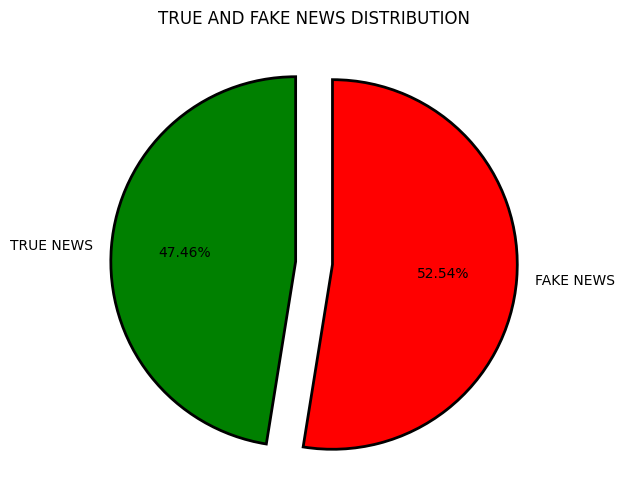

In [92]:

fake_news = df['class'].value_counts()[0]
true_news = df['class'].value_counts()[1]
total_count = len(df)
fake_news_percentage = (fake_news / total_count) * 100
true_news_percentage = (true_news / total_count) * 100

print(fake_news_percentage)
print(true_news_percentage)
value=[true_news_percentage,fake_news_percentage]

plt.figure(figsize=(6,6))
plt.pie(value, labels=['TRUE NEWS', 'FAKE NEWS'],
        autopct='%1.2f%%',
        startangle=90,
        explode=(0.1, 0.1),
        colors='g''r',  
        wedgeprops={'edgecolor': 'black', 'linewidth':2,})
plt.title('TRUE AND FAKE NEWS DISTRIBUTION')
print("__________________________________________________")




subject
Government News     1570
Middle-east          778
News                9050
US_News              783
left-news           4459
politics            6838
politicsNews       11220
worldnews           9991
Name: text, dtype: int64


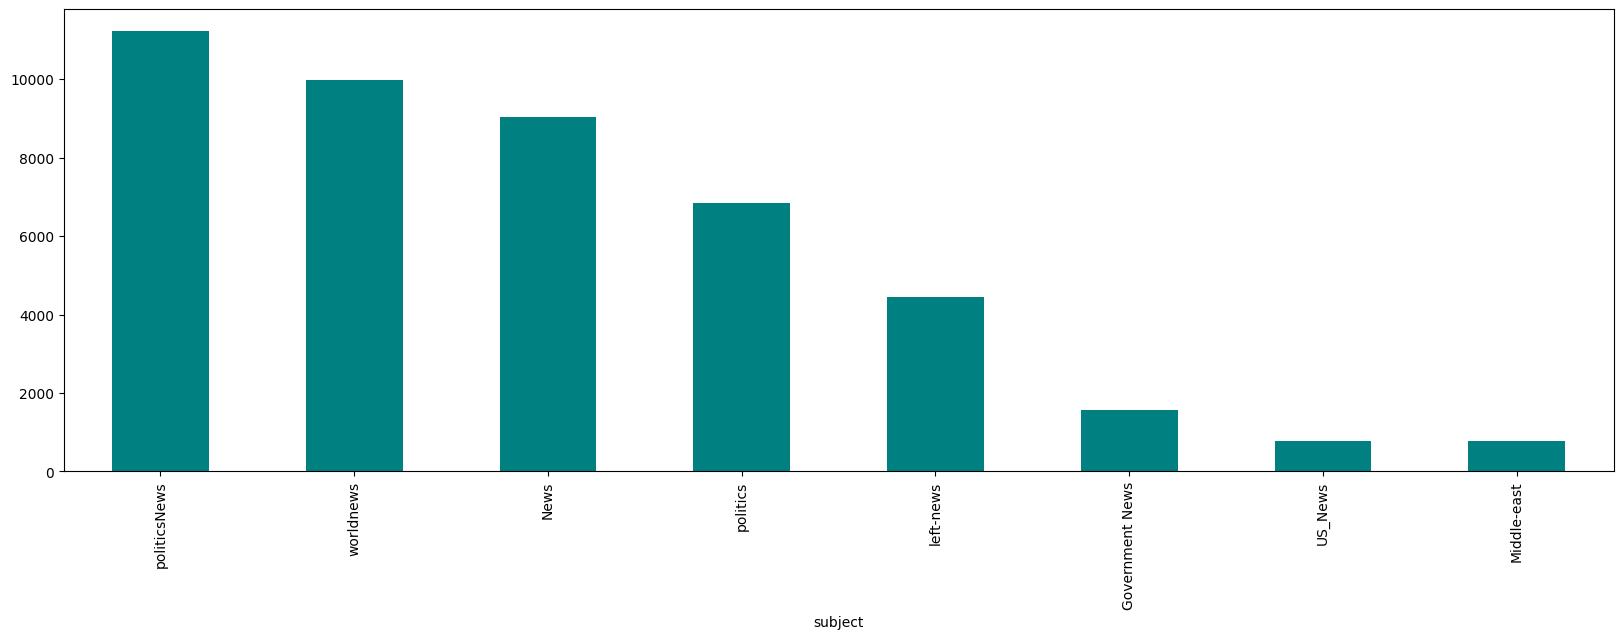

In [93]:
print(df.groupby('subject')['text'].count())
plt.figure(figsize=(20,6))
df['subject'].value_counts().plot(kind='bar',color='#008080')
plt.xticks(rotation='vertical')
plt.show()


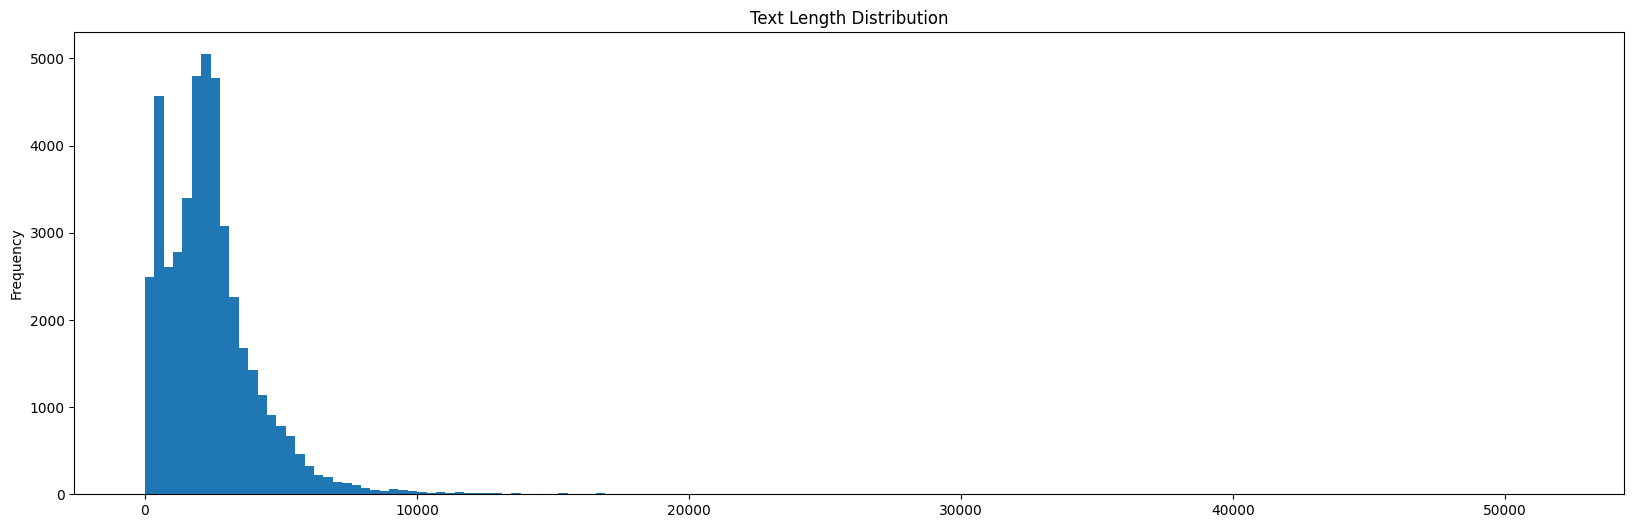

In [94]:
df['text_length'] = df['text'].apply(len)

plt.figure(figsize=(20,6))
df['text_length'].plot(kind='hist', bins=150, title='Text Length Distribution')
plt.show()


In [95]:
def calculate_avg_word_length(text):
    words = text.split()
    total_word_length = sum(len(word) for word in words)
    total_words = len(words)
    
    if total_words == 0:  
        return 0
    else:
        return total_word_length / total_words

df['avg_word_length'] = df['text'].apply(calculate_avg_word_length)


In [96]:
df = df.sample(frac=1)

In [97]:
df.reset_index(inplace=True)
df.drop(["index"],axis=1, inplace=True)

In [98]:
df = df.drop(["title","subject","date"], axis=1)

In [99]:
df

,text,class,content,text_length,avg_word_length
0,Tony Schwartz is a man who knows Donald Trump ...,0,trumps ghostwriter issues dire warning about ...,2302,4.829949
1,Given the fact that Donald Trump has often bra...,0,report turns out most of trumps charity was g...,3830,4.673105
2,It s always fun when Hollywood shows a conserv...,0,actor rob lowe blasts greedy socialist bernie ...,1221,4.936275
3,You know things are going badly for the GOP Pr...,0,even fox news is turning against trump calls ...,2352,4.723039
4,WASHINGTON (Reuters) - The White House is eage...,1,us canada put pipeline fight in the past with ...,2461,5.079208
...,...,...,...,...,...
44684,WASHINGTON (Reuters) - Coal mining executive R...,1,coal ceo pressing trump to speak up for miners...,2582,5.155131
44685,MILWAUKEE (Reuters) - Republican presidential ...,1,trump makes late push for support on eve of wi...,5674,4.775967
44686,Liberals would like you to believe they re mor...,0,exposed why a liberals defense of radical isla...,942,5.408163
44687,The city s first transgender police officer wa...,0,triggered police officer kicked out of event f...,1874,5.237458


In [102]:
X = df["content"]
y = df["class"]

In [103]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorization = TfidfVectorizer(
    stop_words='english',
    max_df=0.7,
    min_df=2,
    ngram_range=(1,2)
)


In [105]:
xv_train = vectorization.fit_transform(x_train)
xv_test = vectorization.transform(x_test)


In [106]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
lr = LogisticRegression()
lr.fit(xv_train,y_train)
logistic_y_pred=lr.predict(xv_test)
accuracy_score_lr=accuracy_score(logistic_y_pred,y_test)
print("____predicted values are____ :\n\n{}".format(logistic_y_pred))
print("\n____accuracy_score is____: \n\n{}".format(accuracy_score_lr))
print("\nconfusion matrix is____: \n\n{}".format(confusion_matrix(logistic_y_pred,y_test)))
print("\n____clasification report is:____\n")
print( classification_report(logistic_y_pred,y_test))


____predicted values are____ :

[0 1 1 ... 0 0 1]

____accuracy_score is____: 

0.9884543094961067

confusion matrix is____: 

[[5781   40]
 [  89 5263]]

____clasification report is:____

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      5821
           1       0.99      0.98      0.99      5352

    accuracy                           0.99     11173
   macro avg       0.99      0.99      0.99     11173
weighted avg       0.99      0.99      0.99     11173



In [107]:
parameters_lr = {'penalty':('l1', 'l2', 'elasticnet'),
              'solver':('lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'),
              'C':[1,10,20]}

clf_lr=GridSearchCV(lr,param_grid=parameters_lr,cv=5,n_jobs=-1) 
clf_lr.fit(xv_train,y_train)
final_lr_parameter=clf_lr.best_params_
final_lr_score=clf_lr.best_score_


In [108]:
final_lr_score

np.float64(0.9968671456552244)

In [109]:
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
mnb = MultinomialNB()
mnb.fit(xv_train,y_train)
mnb_y_pred=mnb.predict(xv_test)
accuracy_score_mnb=accuracy_score(mnb_y_pred,y_test)
print("____predicted values are____ :\n\n{}".format(mnb_y_pred))
print("\nconfusion matrix is____: \n\n{}".format(confusion_matrix(mnb_y_pred,y_test)))
print("\naccuracy_score is____: \n\n{}".format(accuracy_score_mnb))
print("\n____clasification report is:____\n")
print(classification_report(mnb_y_pred,y_test))











____predicted values are____ :

[0 1 1 ... 0 0 1]

confusion matrix is____: 

[[5617  172]
 [ 253 5131]]

accuracy_score is____: 

0.9619618723708941

____clasification report is:____

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      5789
           1       0.97      0.95      0.96      5384

    accuracy                           0.96     11173
   macro avg       0.96      0.96      0.96     11173
weighted avg       0.96      0.96      0.96     11173



In [110]:
parameters_mnb = {'alpha': [0.1, 1.0, 10.0]}

clf_mnb=GridSearchCV(mnb,param_grid=parameters_mnb,cv=5,n_jobs=-1) 
clf_mnb.fit(xv_train,y_train)
final_mnb_parameter=clf_mnb.best_params_
final_mnb_score=clf_mnb.best_score_

In [111]:
final_mnb_score

np.float64(0.9702531139656415)

In [112]:
final_model=pd.DataFrame({
                        'Model': ['Logistic Regression',
                                   'MultinomialNB'],
                         'Accuracy': [accuracy_score_lr,accuracy_score_mnb],
                        'Final_Model':['Logistic Regression',
                                   'MultinomialNB'],
                        'Final_Accuracy':[final_lr_score,final_mnb_score]})


In [113]:
final_model

,Model,Accuracy,Final_Model,Final_Accuracy
0,Logistic Regression,0.988454,Logistic Regression,0.996867
1,MultinomialNB,0.961962,MultinomialNB,0.970253


In [114]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(xv_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [115]:
y_pred = model.predict(xv_test)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.9881858050657836


In [116]:
import pickle

pickle.dump(model, open('../model/model_lr.pkl', 'wb'))
pickle.dump(vectorization, open('../model/vectorization.pkl', 'wb'))